# Preparing Dataset
**Importing Dependencies**

In [ ]:
import os
from os.path import isfile
import pandas as pd
import matplotlib.pyplot as plt
import random
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from keras.preprocessing.image import load_img
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D

**Loading dataset**

In [ ]:
import os
print(os.listdir('/content/'))


['.config', 'sample_data']


In [ ]:
from google.colab import drive
import zipfile
import os

# Mount Google Drive (if your file is in Drive)
drive.mount('/content/drive')

# Path to your zip file
zip_path = '/content/drive/MyDrive/DribyaDristi/asl_alphabet_train.zip'

# Extract the zip file
extract_path = '/content/asl_dataset'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset extracted successfully!


In [ ]:
dataset_path="/content/asl_dataset/asl_alphabet_train"

Getting image paths

In [ ]:
def getImagePaths(dataset_path):
    image_paths = []
    for root, dirs, files in os.walk(dataset_path):
      for file in files:
          image_paths.append(os.path.join(root, file))
    return image_paths

image_paths=getImagePaths(dataset_path)
print(len(image_paths))
train_paths, test_paths = train_test_split(image_paths, test_size=0.2, random_state=42)

87000


Creating data frame

In [ ]:
def createDataFrame(image_paths):
    labels = [os.path.basename(os.path.dirname(path)) for path in image_paths]
    df = pd.DataFrame({'image': image_paths, 'label': labels})
    return df
train=createDataFrame(train_paths)
test=createDataFrame(test_paths)

In [ ]:
print(len(image_paths))
print(len(train_paths))
print(len(test_paths))
print(train)
print(test)

87000
69600
17400
                                                   image label
0      /content/asl_dataset/asl_alphabet_train/K/K250...     K
1      /content/asl_dataset/asl_alphabet_train/J/J168...     J
2      /content/asl_dataset/asl_alphabet_train/D/D192...     D
3      /content/asl_dataset/asl_alphabet_train/J/J120...     J
4      /content/asl_dataset/asl_alphabet_train/Y/Y115...     Y
...                                                  ...   ...
69595  /content/asl_dataset/asl_alphabet_train/S/S229...     S
69596  /content/asl_dataset/asl_alphabet_train/Y/Y154...     Y
69597  /content/asl_dataset/asl_alphabet_train/W/W109...     W
69598  /content/asl_dataset/asl_alphabet_train/H/H187...     H
69599   /content/asl_dataset/asl_alphabet_train/N/N2.jpg     N

[69600 rows x 2 columns]
                                                   image    label
0      /content/asl_dataset/asl_alphabet_train/I/I361...        I
1      /content/asl_dataset/asl_alphabet_train/A/A278...        A
2 

In [ ]:
from tqdm.notebook import tqdm

In [ ]:
def extract_features(images):
    features = []
    for image in tqdm(images):
        img = load_img(image, color_mode =  "grayscale" , target_size=(48, 48))
        img = np.array(img)
        features.append(img)
    features = np.array(features)
    features = features.reshape(len(features),48,48,1)
    return features

train_features = extract_features(train['image'])
test_features = extract_features(test['image'])
x_train = train_features/255.0
x_test = test_features/255.0

  0%|          | 0/69600 [00:00<?, ?it/s]

  0%|          | 0/17400 [00:00<?, ?it/s]

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(train['label'])
LabelEncoder()

y_train = le.transform(train['label'])
y_test = le.transform(test['label'])


In [ ]:
num_classes = train['label'].nunique()
print(f"Number of unique classes: {num_classes}")

y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

Number of unique classes: 29


In [ ]:
print(x_train.shape)
print(y_train.shape)
label_order = le.classes_
print("Label order:", label_order)

(69600, 48, 48, 1)
(69600, 29)
Label order: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z' 'del' 'nothing' 'space']


Showing random image from the dataset

Random image path: /content/asl_dataset/asl_alphabet_train/C/C67.jpg


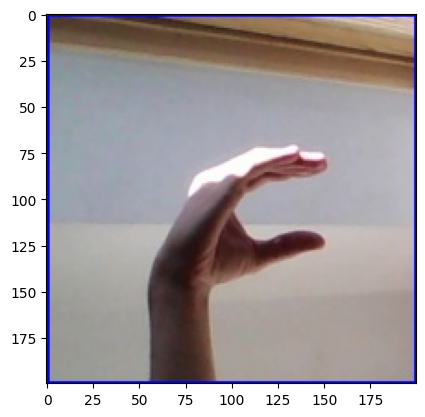

In [ ]:
def showRandomImage(image_paths):
  random_image_path = random.choice(image_paths)
  print("Random image path:", random_image_path)
  image = plt.imread(random_image_path)
  plt.imshow(image)
  plt.show()

showRandomImage(image_paths)

**Pre-process the image**

In [ ]:
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D

**Build the CNN Model**

In [ ]:
model = Sequential()
# convolutional layers
model.add(Conv2D(128, kernel_size=(3,3), activation='relu', input_shape=(48,48,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(256, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Flatten())
# fully connected layers
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
# output layer
model.add(Dense(num_classes, activation='softmax')) # num_classes should be 29 or equal to the actual number of classes in your dataset

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'] )

In [ ]:
model.fit(x= x_train,y = y_train, batch_size = 128, epochs = 20, validation_data = (x_test,y_test))

Epoch 1/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 44s 81ms/step - accuracy: 0.3597 - loss: 2.0596 - val_accuracy: 0.9064 - val_loss: 0.2785
Epoch 2/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 65s 50ms/step - accuracy: 0.8557 - loss: 0.4213 - val_accuracy: 0.9660 - val_loss: 0.1043
Epoch 3/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.9198 - loss: 0.2404 - val_accuracy: 0.9847 - val_loss: 0.0521
Epoch 4/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.9461 - loss: 0.1705 - val_accuracy: 0.9931 - val_loss: 0.0281
Epoch 5/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.9541 - loss: 0.1459 - val_accuracy: 0.9951 - val_loss: 0.0188
Epoch 6/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 27s 50ms/step - accuracy: 0.9628 - loss: 0.1164 - val_accuracy: 0.9959 - val_loss: 0.0156
Epoch 7/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.9687 - loss: 0.1033 - val_accuracy: 0.9965 - val_loss: 0.0125
Epoch 8/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.9689 - loss: 0.0999 - 

In [ ]:
model_json = model.to_json()
with open("DribyaDristi.json",'w') as json_file:
    json_file.write(model_json)
model.save("Dribya_Dristi.h5")

In [ ]:
import shutil
from google.colab import files

# Path to your folder
folder_path = '/content/DribyaDristi'

# Name of the zip file
zip_file = 'DribyaDristi.zip'

# Zip the folder
shutil.make_archive('DribyaDristi', 'zip', folder_path)

# Download the zipped file
files.download(zip_file)

FileNotFoundError: [Errno 2] No such file or directory: '/content/DribyaDristi'

In [ ]:
import io
import matplotlib.pyplot as plt
from tensorflow import keras

# Path to the directory containing the saved model
model_path = '/content/Dribya_Dristi.h5'

# Load the model
model = keras.models.load_model(model_path)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,237,855 (16.17 MB)

 Trainable params: 4,237,853 (16.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
print(model.input_shape)

(None, 48, 48, 1)


NameError: name 'model' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Random image path: /content/asl_dataset/asl_alphabet_train/H/H1891.jpg


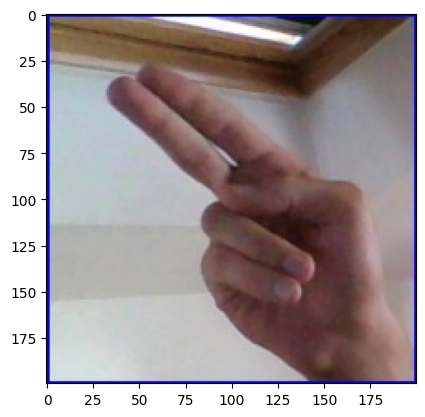

In [ ]:
def showRandomImage(image_paths):
  random_image_path = random.choice(image_paths)
  print("Random image path:", random_image_path)
  image = plt.imread(random_image_path)
  plt.imshow(image)
  plt.show()

showRandomImage(image_paths)

In [ ]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np

def ef(image):
    img = load_img(image,color_mode =  "grayscale",target_size=(48, 48) )
    feature = np.array(img)
    feature = feature.reshape(1,48,48,1)
    return feature/255.0

label = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']

def showRandomImage(image_paths):
  random_image_path = random.choice(image_paths)
  print(random_image_path)
  return random_image_path



image = showRandomImage(image_paths)
img = ef(image)
pred = model.predict(img)
# print(pred.argmax())
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)

/content/asl_dataset/asl_alphabet_train/W/W2612.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
model prediction is  W
